# EMTA data analysis

## Configurations 

In [1]:
from typing import Callable

import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Import files

In [2]:
#Pandas import
data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv")
data_raw_previous_years = pd.read_csv("tasutud_maksud_varasemad_aastad.csv")

#Duckdb import example
duckdb.sql("""
    FROM "tasutud_maksud_varasemad_aastad.csv"
""").df()

#Võrdleme, kas tabelite veergude pealkirjad on samad
#data_raw_this_year.columns == data_raw_previous_years.columns


C:\Users\opilane\AppData\Local\Temp\ipykernel_12372\4125559646.py:2: DtypeWarning: Columns (0: Registrikood) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv")
C:\Users\opilane\AppData\Local\Temp\ipykernel_12372\4125559646.py:3: DtypeWarning: Columns (0: Registrikood, 1: Maakond) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw_previous_years = pd.read_csv("tasutud_maksud_varasemad_aastad.csv")


,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2022,<NA>,288,<NA>,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2023,<NA>,288,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,288,52,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-04-10,01834575,"KUNDERI 24, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,<NA>,<NA>,268,...,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,1300554,1645555,1185273,...,923188,950362,22930261,31976194,26140614,31599227,214,228,231,232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642133,2026-04-10,OO000012,HANDELSBOLAGET KORSVÄGEN FÖRVALTING,Mitteresident,NaN,NaN,2024,2,13,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
642134,2026-04-10,OO000015,TRUST FINANCING AB,Mitteresident,NaN,NaN,2024,<NA>,83,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
642135,2026-04-10,QQ000003,RAUMASTER OY,Mitteresident,NaN,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,24114,18514,21953,...,21802,22937,26908,26851,86902,23302,3,3,3,3
642136,2026-04-10,QQ000003,RAUMASTER OY,Mitteresident,NaN,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2023,23447,20816,23767,...,24487,23491,18309,19522,7596,47353,3,3,3,4


## Sort and organize the data

In [3]:
# Kombineerime tabelid vertikaalselt kasutades UNION ALL funktsiooni
united_data_raw = duckdb.sql("""
    FROM "tasutud_maksud_kaesolev_aasta.csv"
    UNION ALL
    FROM "tasutud_maksud_varasemad_aastad.csv"
""")

#Unpivot kvartalite veerud (I, II, III, IV) eraldi ridadele
united_data_raw_unpivot = duckdb.sql("""
WITH base AS (
    SELECT
        "Andmete seis",
        "Registrikood",
        "Nimi",
        "Liik",
        "Maakond",
        "Tegevusala",
        "Aasta",
        "Riiklikud maksud I kv" AS riiklikud_maksud_1,
        "Riiklikud maksud II kv" AS riiklikud_maksud_2,
        "Riiklikud maksud III kv" AS riiklikud_maksud_3,
        "Riiklikud maksud IV kv" AS riiklikud_maksud_4,
        "Tööjõumaksud I kv" AS toojou_maksud_1,
        "Tööjõumaksud II kv" AS toojou_maksud_2,
        "Tööjõumaksud III kv" AS toojou_maksud_3,
        "Tööjõumaksud IV kv" AS toojou_maksud_4,
        "Käive I kv" AS kaive_1,
        "Käive II kv" AS kaive_2,
        "Käive III kv" AS kaive_3,
        "Käive IV kv" AS kaive_4,
        "Töötajate arv I kv" AS tootajad_1,
        "Töötajate arv II kv" AS tootajad_2,
        "Töötajate arv III kv" AS tootajad_3,
        "Töötajate arv IV kv" AS tootajad_4
    FROM united_data_raw
)
UNPIVOT base
ON
    (riiklikud_maksud_1, toojou_maksud_1, kaive_1, tootajad_1),
    (riiklikud_maksud_2, toojou_maksud_2, kaive_2, tootajad_2),
    (riiklikud_maksud_3, toojou_maksud_3, kaive_3, tootajad_3),
    (riiklikud_maksud_4, toojou_maksud_4, kaive_4, tootajad_4)
INTO
    NAME kvartal
    VALUE riiklikud_maksud, toojoumaksud, kaive, tootajate_arv;
""")

#Näita uut tabelit
united_data_raw_unpivot

┌──────────────┬──────────────┬─────────────────────────┬──────────┬─────────────────────────────┬─────────────────────────────────────────────────────────────────┬───────┬───────────────────────────────────────────────────────┬──────────────────┬──────────────┬──────────┬───────────────┐
│ Andmete seis │ Registrikood │          Nimi           │   Liik   │           Maakond           │                           Tegevusala                            │ Aasta │                        kvartal                        │ riiklikud_maksud │ toojoumaksud │  kaive   │ tootajate_arv │
│     date     │   varchar    │         varchar         │ varchar  │           varchar           │                             varchar                             │ int64 │                        varchar                        │      int64       │    int64     │  int64   │     int64     │
├──────────────┼──────────────┼─────────────────────────┼──────────┼─────────────────────────────┼────────────────────────────────

In [54]:
# Eraldame maakonna tabelist maakonna
def separate_maakond(maakond: str) -> str:
    return maakond.split(" ( ")[0]

# Eraldame maakonna tabelist kov
def separate_kov(maakond: str) -> str:
    return maakond.split(" ( ")[1][:-2]

# Muudame kvartali väärtused numbriteks, s.t võtame stringist viimase numbri. Nt "riiklikud_maksud_3_toojou_maksud_3_kaive_3_tootajad_3" -> 3
def kvartal_last_number(kvartal: str) -> int:
    return int(kvartal[-1])

def peamine_tegevusala(tegevusala: str) -> str:
    return tegevusala.split(";")[0]

# Abifunktsioon, mis käivitab try except loogika, et vältida funktsioonide loomisel errorit
def _register_duckdb_function(duckdb_function_name: str, function: Callable) -> None:
    try:
        duckdb.remove_function(duckdb_function_name)
    except:
        pass
    duckdb.create_function(duckdb_function_name, function) 

# Jooksutame abifunktsiooni
_register_duckdb_function("separate_maakond", separate_maakond)
_register_duckdb_function("separate_kov", separate_kov)
_register_duckdb_function("kvartal_last_number", kvartal_last_number)
_register_duckdb_function("peamine_tegevusala", peamine_tegevusala)
    

In [59]:
# Loome uue organiseeritud tabeli, kus kasutame ka SQL siseseid funktsioone
emta_data = duckdb.sql("""
    SELECT
        Registrikood AS registrikood,
        Nimi AS nimi,
        Liik AS liik,
        separate_maakond(Maakond) AS maakond,
        separate_kov(Maakond) AS kov,
        peamine_tegevusala(Tegevusala) AS tegevusala,
        Aasta AS aasta,
        kvartal_last_number(Kvartal) AS kvartal,
        riiklikud_maksud,
        toojoumaksud,
        kaive,
        tootajate_arv
    FROM 
        united_data_raw_unpivot;
""").df()
emta_data

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


## Data analysis

In [ ]:
# Summeerime andmed, et saada lihtsakoeline ülevaade
duckdb.sql("""
    SUMMARIZE emta_data
""").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,registrikood,VARCHAR,10000018,QQ000003,65561,NaN,NaN,NaN,NaN,NaN,943934,0.00
1,nimi,VARCHAR,"""CAMPO DI FIORI"" OÜ","ŽUR, OÜ",74719,NaN,NaN,NaN,NaN,NaN,943934,0.00
2,liik,VARCHAR,FIE,Äriühing,6,NaN,NaN,NaN,NaN,NaN,943934,0.00
3,maakond,VARCHAR,Harju,Võru,15,NaN,NaN,NaN,NaN,NaN,943934,1.42
4,kov,VARCHAR,Alutaguse vald,Võru vald,67,NaN,NaN,NaN,NaN,NaN,943934,1.42
5,tegevusala,VARCHAR,AVALIK HALDUS JA RIIGIKAITSE; KOHUSTUSLIK SOTS...,VEONDUS JA LAONDUS,18,NaN,NaN,NaN,NaN,NaN,943934,0.02
6,aasta,BIGINT,2022,2026,5,2023.6594751327953,1.2346074289851505,2023,2024,2025,943934,0.00
7,kvartal,BIGINT,1,4,4,2.416136085785659,1.1409601799199436,1,2,3,943934,0.00
8,riiklikud_maksud,BIGINT,0,73579235,142327,55152.88020984518,598370.9273718507,1842,5408,18027,943934,0.00
9,toojoumaksud,BIGINT,0,69827627,90547,27812.142454875022,301112.4524446314,1020,2736,9323,943934,0.00


In [60]:
# Kõrgeima töötajate arvuga ettevõte
duckdb.sql("""
    SELECT nimi, tootajate_arv
    FROM emta_data
    ORDER BY tootajate_arv DESC
    LIMIT 1;
""").df()

,nimi,tootajate_arv
0,TARTU ÜLIKOOL,5778


In [61]:
# Ettevõtete arv maakondade kaupa ning nende keskmine käive 2026 I kvartalis
duckdb.sql("""
    SELECT
        count(registrikood) AS ettevotete_arv,
        maakond,
        ROUND(AVG(kaive), 0)::int AS keskmine_kvartaalne_kaive,
        ROUND(AVG(kaive/3), 0)::int AS keskmine_kuine_kaive
    FROM emta_data
    WHERE aasta = 2026 AND kvartal = 1
    GROUP BY maakond
    ORDER BY keskmine_kvartaalne_kaive DESC;
""")

┌────────────────┬────────────┬───────────────────────────┬──────────────────────┐
│ ettevotete_arv │  maakond   │ keskmine_kvartaalne_kaive │ keskmine_kuine_kaive │
│     int64      │  varchar   │           int32           │        int32         │
├────────────────┼────────────┼───────────────────────────┼──────────────────────┤
│            141 │ NULL       │                    762548 │               254183 │
│          31202 │ Harju      │                    605799 │               201933 │
│            936 │ Järva      │                    374131 │               124710 │
│           6616 │ Tartu      │                    361536 │               120512 │
│           2095 │ Lääne-Viru │                    317690 │               105897 │
│           1723 │ Viljandi   │                    266402 │                88801 │
│            839 │ Valga      │                    244664 │                81555 │
│            949 │ Jõgeva     │                    241184 │                80395 │
│   

<Axes: xlabel='tootajate_arv', ylabel='tegevusala'>

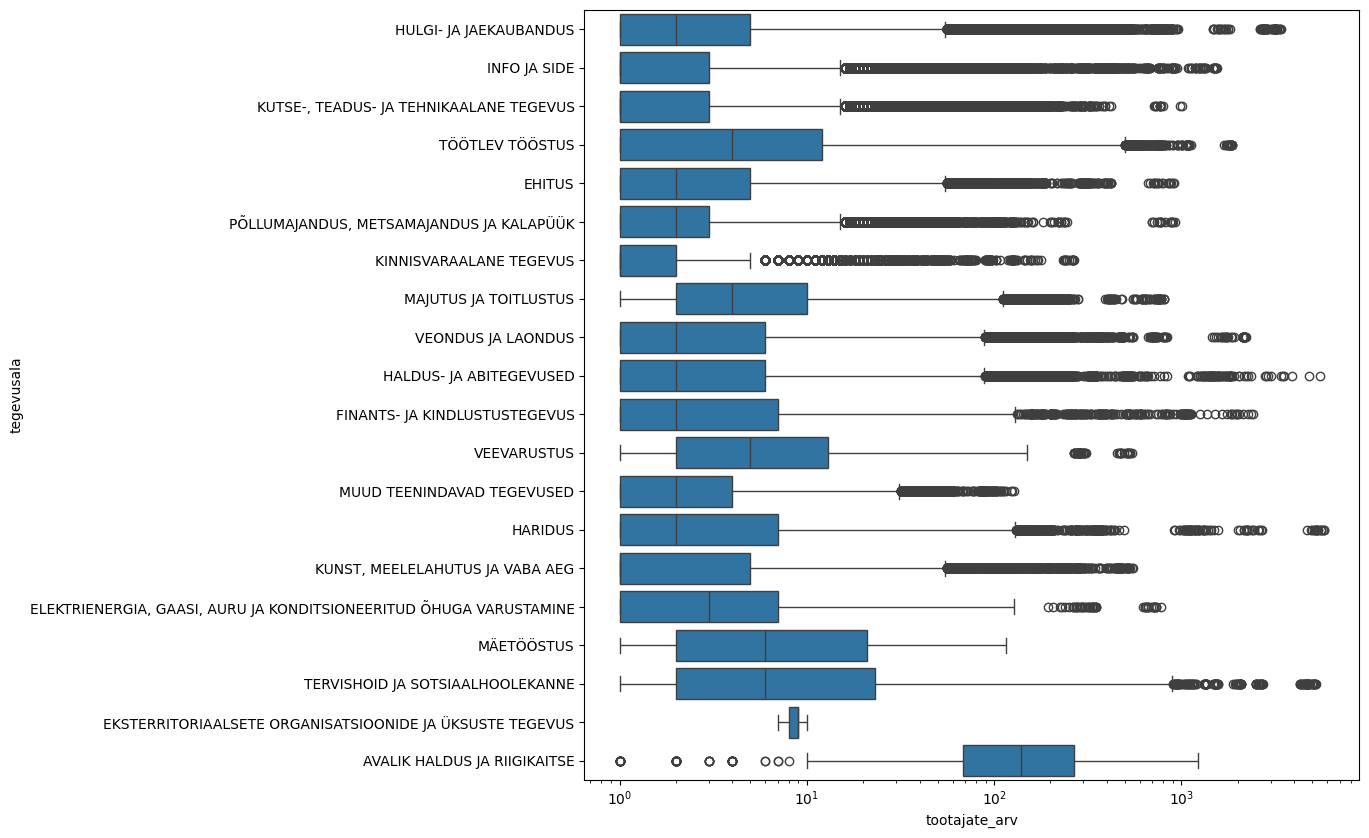

In [90]:
# Boxplot tegevusalad töötajate arvu järgi
plt.figure(1, figsize =(10, 10))
sns.boxplot(emta_data, y = "tegevusala", x = "tootajate_arv", log_scale = 10)

#Alternatiiv
#ax.sns.boxplot(emta_data, y = "tegevusala", x = "tootajate_arv")
#ax.set_xscale("log")

## Töötajate ja käibe suhe

<Axes: xlabel='avg_tootajate_arv', ylabel='avg_kaive'>

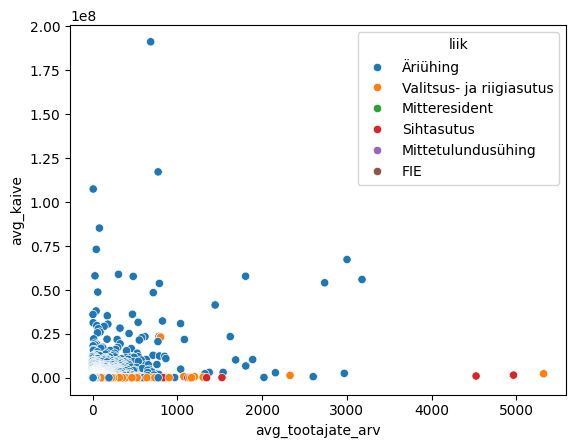

In [112]:


avg_revenue = duckdb.sql("""
    SELECT 
        nimi, 
        round(avg(kaive / 3), 0)::int as avg_kaive,
        round(avg(tootajate_arv))::int as avg_tootajate_arv,
        liik,
        any_value(maakond) AS maakond
    FROM emta_data
    GROUP BY nimi, liik
    ORDER BY avg_kaive DESC;
""").df()

sns.scatterplot(avg_revenue, x = "avg_tootajate_arv", y = "avg_kaive", hue = "liik")

<Axes: xlabel='avg_tootajate_arv', ylabel='avg_kaive'>

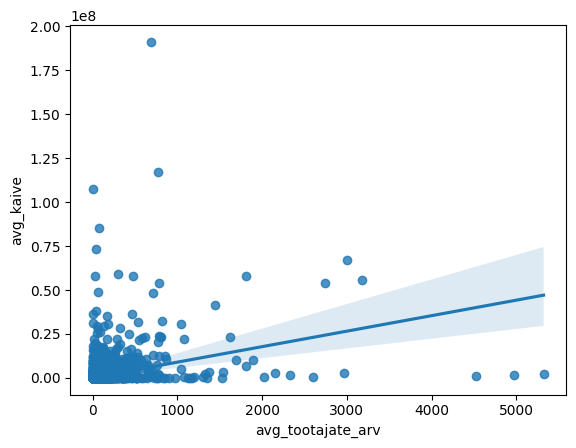

In [111]:
sns.regplot(avg_revenue, x = "avg_tootajate_arv", y = "avg_kaive")

In [114]:
# Statistiline testimine:

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    duckdb.sql("SELECT avg_kaive FROM avg_revenue WHERE maakond = 'Tartu' AND avg_kaive IS NOT NULL").df()["avg_kaive"],
    duckdb.sql("SELECT avg_kaive FROM avg_revenue WHERE maakond = 'Pärnu' AND avg_kaive IS NOT NULL").df()["avg_kaive"],
    alternative='two-sided'
)
print(f"{p:.15f}")

0.000000000058478


## Data to CSV

In [93]:
emta_data.to_csv("emta_data.csv", index = False)